<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\rushi\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\rushi\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [3]:
# Read the CSV file
df = pd.read_csv('survey_data_cleaned_eda.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,YearsCodePro_num,JobSat_num,ExperienceRange
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,8.0,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,NaN,NaN,NaN,8.0,17.0,8.0,10-20
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,Appropriate in length,Easy,NaN,8.0,27.0,8.0,>20
3,4,I am learning to code,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,Too long,Easy,NaN,8.0,NaN,8.0,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,Too short,Easy,NaN,8.0,NaN,8.0,NaN


In [ ]:
import sqlite3


conn = sqlite3.connect('survey-data.sqlite')


df.to_sql('main', conn, if_exists='replace', index=False)



conn.close()


In [ ]:

conn = sqlite3.connect('survey-data.sqlite')
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)


print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment                            RemoteWork   Check  \
0  Employed, full-time                                Remote  Apples   
1  Employed, full-time                                Remote  Apples   
2  Employed, full-time                                Remote  Apples   
3   Student, full-time  Hybrid (some remote, some in-person)  Apples   
4   Student, full-time  Hybrid (some remote, some in-person)  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source proje

In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


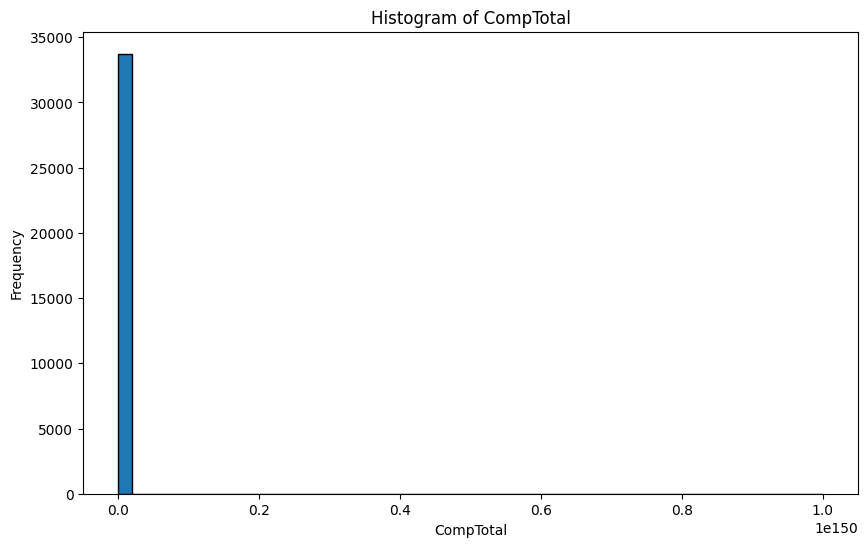

In [10]:
# Histograms: Plot a histogram of CompTotal

QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
hist_df = pd.read_sql_query(QUERY, conn)

hist_df['CompTotal'] = pd.to_numeric(hist_df['CompTotal'], errors='coerce')
hist_df = hist_df.dropna()

plt.figure(figsize=(10, 6))
plt.hist(hist_df['CompTotal'], bins=50, edgecolor='black')
plt.title('Histogram of CompTotal')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')
plt.show()

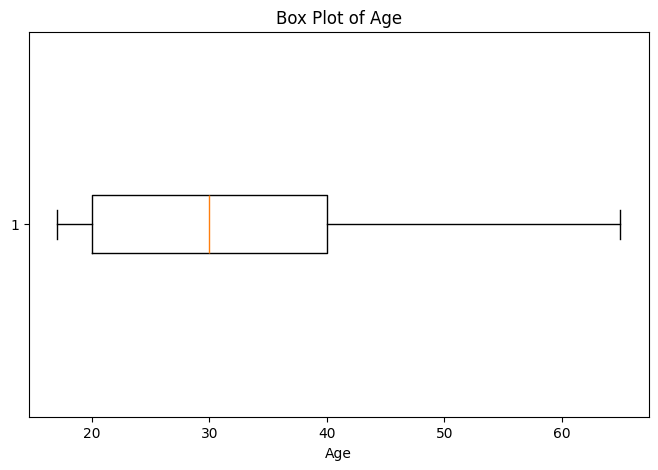

In [12]:
# Box Plots: Plot a box plot of Age
# Box Plots: Plot a box plot of Age

import re

def parse_age_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip()

    age_map = {
        'Under 18 years old': 17,
        '18-24 years old': 20,
        '25-34 years old': 30,
        '35-44 years old': 40,
        '45-54 years old': 50,
        '55-64 years old': 60,
        '65 years or older': 65,
        'Prefer not to say': float('nan')
    }

    if text in age_map:
        return age_map[text]

    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]
    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""
age_df = pd.read_sql_query(QUERY, conn)

age_df['Age_numeric'] = age_df['Age'].apply(parse_age_value)
age_df = age_df.dropna(subset=['Age_numeric'])

plt.figure(figsize=(8, 5))
plt.boxplot(age_df['Age_numeric'], vert=False)
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()













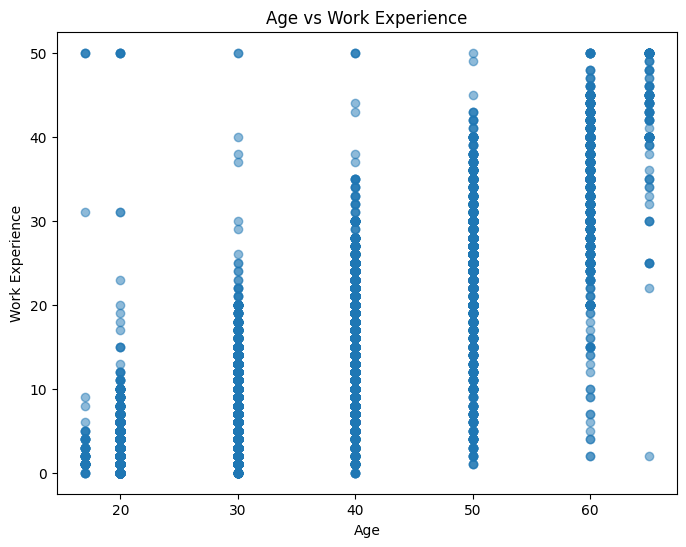

In [15]:
# Scatter Plots: Create a scatter plot of Age and WorkExp

import re

def parse_age_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip()

    age_map = {
        'Under 18 years old': 17,
        '18-24 years old': 20,
        '25-34 years old': 30,
        '35-44 years old': 40,
        '45-54 years old': 50,
        '55-64 years old': 60,
        '65 years or older': 65,
        'Prefer not to say': float('nan')
    }

    if text in age_map:
        return age_map[text]

    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]
    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

def parse_numeric_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip()
    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]

    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

QUERY = """
SELECT Age, WorkExp
FROM main
WHERE Age IS NOT NULL AND WorkExp IS NOT NULL
"""
scatter_df = pd.read_sql_query(QUERY, conn)

scatter_df['Age_numeric'] = scatter_df['Age'].apply(parse_age_value)
scatter_df['WorkExp_numeric'] = scatter_df['WorkExp'].apply(parse_numeric_value)
scatter_df = scatter_df.dropna(subset=['Age_numeric', 'WorkExp_numeric'])

plt.figure(figsize=(8, 6))
plt.scatter(scatter_df['Age_numeric'], scatter_df['WorkExp_numeric'], alpha=0.5)
plt.title('Age vs Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Experience')
plt.show()

In [ ]:
## Write your code here

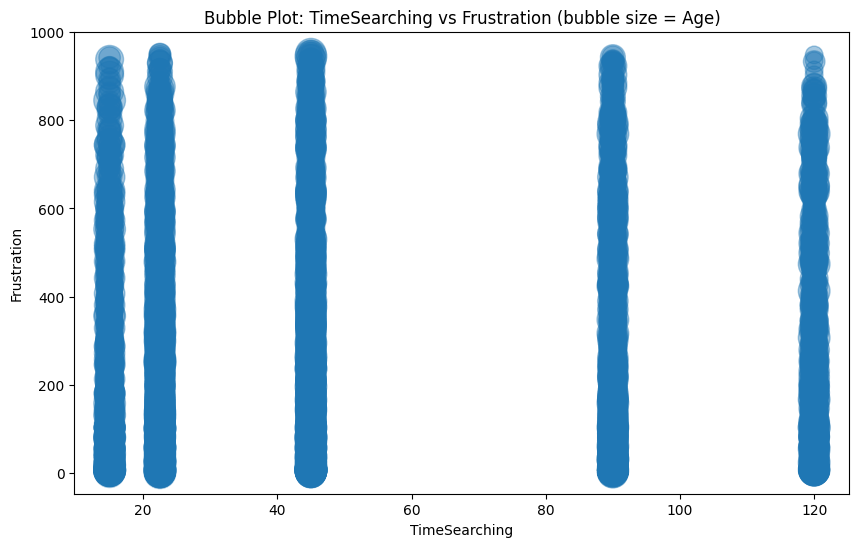

In [16]:
# Bubble Plots: Create a bubble plot of TimeSearching and Frustration using Age as bubble size

QUERY = """
SELECT Age, TimeSearching, Frustration
FROM main
WHERE Age IS NOT NULL AND TimeSearching IS NOT NULL AND Frustration IS NOT NULL
"""
bubble_df = pd.read_sql_query(QUERY, conn)

bubble_df['Age_numeric'] = bubble_df['Age'].apply(parse_age_value)
bubble_df['TimeSearching_numeric'] = bubble_df['TimeSearching'].apply(parse_numeric_value)
bubble_df['Frustration_numeric'] = bubble_df['Frustration'].apply(parse_numeric_value)

frustration_codes = pd.Series(pd.factorize(bubble_df['Frustration'])[0] + 1, index=bubble_df.index)
bubble_df['Frustration_numeric'] = bubble_df['Frustration_numeric'].fillna(frustration_codes)

bubble_df = bubble_df.dropna(subset=['Age_numeric', 'TimeSearching_numeric', 'Frustration_numeric'])

plt.figure(figsize=(10, 6))
plt.scatter(
    bubble_df['TimeSearching_numeric'],
    bubble_df['Frustration_numeric'],
    s=bubble_df['Age_numeric'] * 8,
    alpha=0.4
)
plt.title('Bubble Plot: TimeSearching vs Frustration (bubble size = Age)')
plt.xlabel('TimeSearching')
plt.ylabel('Frustration')
plt.show()

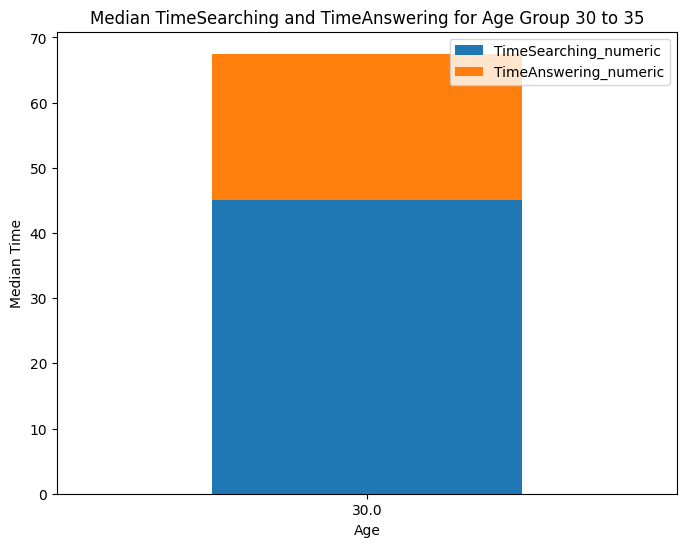

In [17]:
# Stacked Charts: Create a stacked bar chart of median TimeSearching and TimeAnswering for the age group 30 to 35

QUERY = """
SELECT Age, TimeSearching, TimeAnswering
FROM main
WHERE Age IS NOT NULL AND TimeSearching IS NOT NULL AND TimeAnswering IS NOT NULL
"""
stack_df = pd.read_sql_query(QUERY, conn)

stack_df['Age_numeric'] = stack_df['Age'].apply(parse_age_value)
stack_df['TimeSearching_numeric'] = stack_df['TimeSearching'].apply(parse_numeric_value)
stack_df['TimeAnswering_numeric'] = stack_df['TimeAnswering'].apply(parse_numeric_value)

stack_df = stack_df.dropna(subset=['Age_numeric', 'TimeSearching_numeric', 'TimeAnswering_numeric'])
stack_df = stack_df[(stack_df['Age_numeric'] >= 30) & (stack_df['Age_numeric'] <= 35)]

median_stack = stack_df.groupby('Age_numeric')[['TimeSearching_numeric', 'TimeAnswering_numeric']].median()

median_stack.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Median TimeSearching and TimeAnswering for Age Group 30 to 35')
plt.xlabel('Age')
plt.ylabel('Median Time')
plt.xticks(rotation=0)
plt.show()

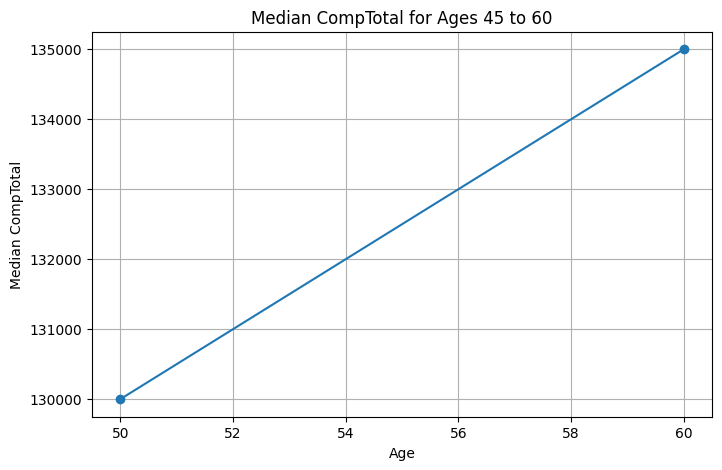

In [18]:
# Line Chart: Plot the median CompTotal for all ages from 45 to 60

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL
"""
line_df = pd.read_sql_query(QUERY, conn)

line_df['Age_numeric'] = line_df['Age'].apply(parse_age_value)
line_df['CompTotal'] = pd.to_numeric(line_df['CompTotal'], errors='coerce')
line_df = line_df.dropna(subset=['Age_numeric', 'CompTotal'])
line_df = line_df[(line_df['Age_numeric'] >= 45) & (line_df['Age_numeric'] <= 60)]

median_comp = line_df.groupby('Age_numeric')['CompTotal'].median().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(median_comp['Age_numeric'], median_comp['CompTotal'], marker='o')
plt.title('Median CompTotal for Ages 45 to 60')
plt.xlabel('Age')
plt.ylabel('Median CompTotal')
plt.grid(True)
plt.show()

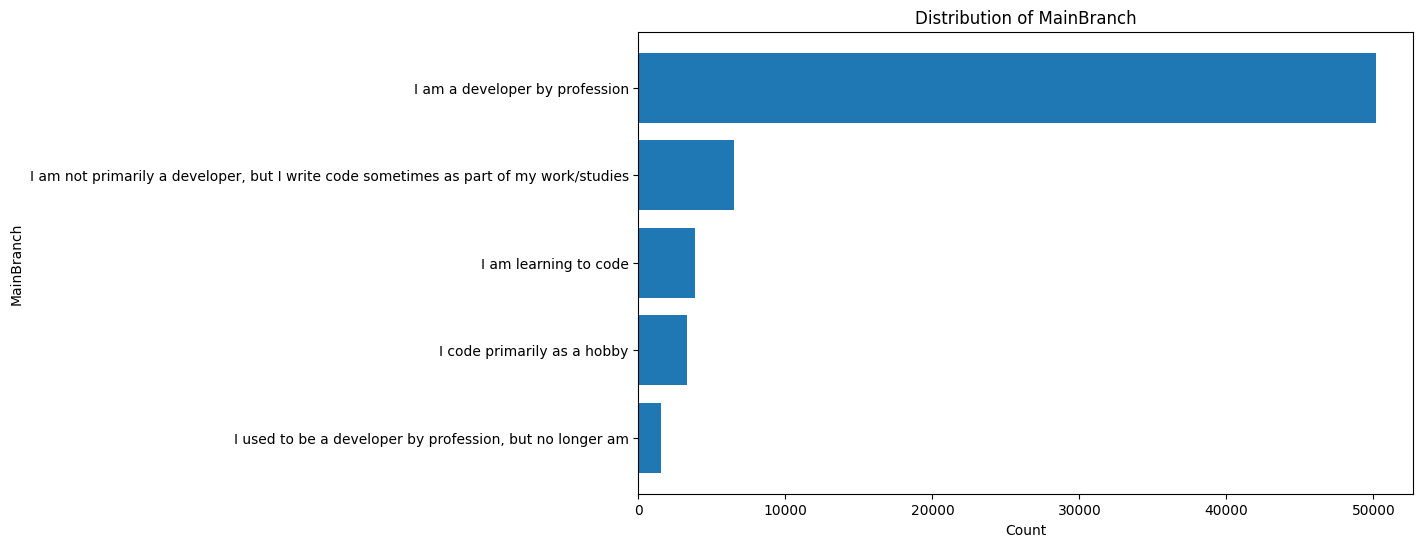

In [19]:
# Bar Chart: Create a horizontal bar chart using the MainBranch column

QUERY = """
SELECT MainBranch, COUNT(*) AS count
FROM main
GROUP BY MainBranch
ORDER BY count DESC
"""
branch_df = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))
plt.barh(branch_df['MainBranch'], branch_df['count'])
plt.title('Distribution of MainBranch')
plt.xlabel('Count')
plt.ylabel('MainBranch')
plt.gca().invert_yaxis()
plt.show()

In [20]:
conn.close()